In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [2]:
#load the datasets
df=pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")


In [3]:
#Overview of datasets
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB
None


In [6]:
#find out nullvalue in datasets
df.isnull().sum()


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [7]:
#check duplicate value
df.duplicated().sum()

np.int64(0)

In [8]:
#Describe the datasets
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


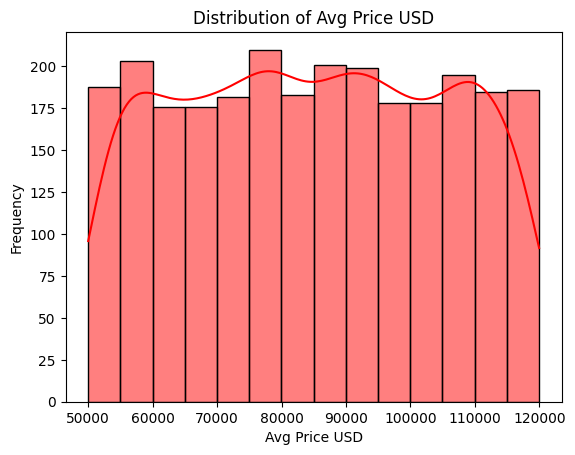

In [9]:
#Distribution of Avg_Price_USD	
sns.histplot(df['Avg_Price_USD'],kde=True,color='red')
plt.xlabel('Avg Price USD')
plt.ylabel('Frequency')
plt.title('Distribution of Avg Price USD')
plt.show()

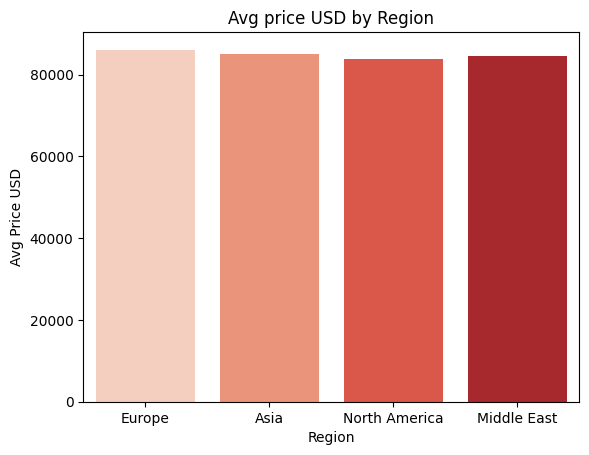

In [12]:
#Avg Price USD By Region
sns.barplot(x='Region',y='Avg_Price_USD',data=df , ci=False,palette='Reds')
plt.xlabel('Region')
plt.ylabel('Avg Price USD')
plt.title('Avg price USD by Region')
plt.show()

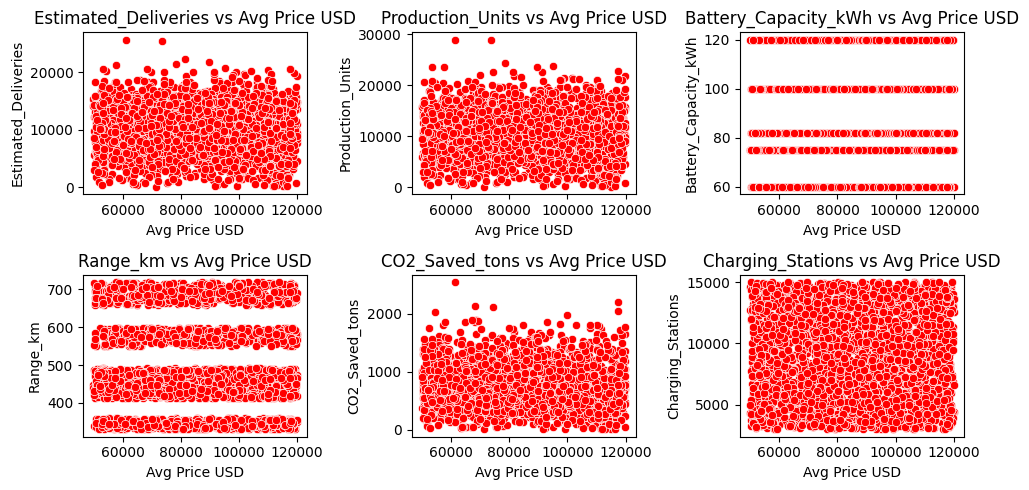

In [30]:
#Scatter Plots
cols_scatter = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols_scatter:
    plt.subplot(2,3,cols_scatter.index(col)+1)
    sns.scatterplot(x=df['Avg_Price_USD'],y=df[col],color='red')
    plt.xlabel('Avg Price USD')
    plt.ylabel(col)
    plt.title(f'{col} vs Avg Price USD')
plt.tight_layout()
plt.show()


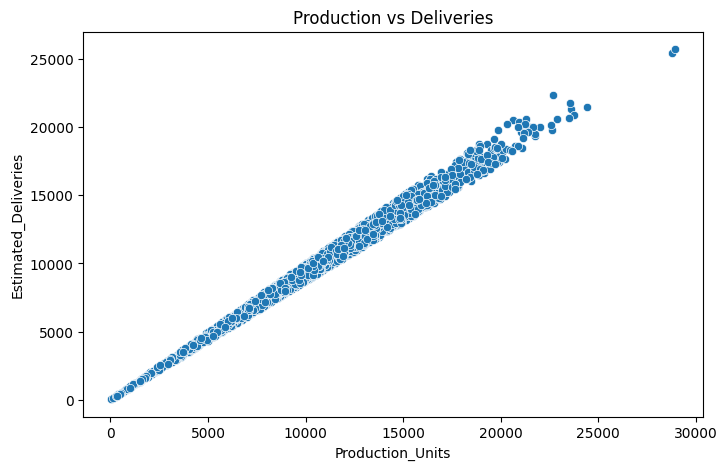

In [ ]:
# Scatter Plot: Production Units vs Estimated Deliveries
# This visualization helps analyze the relationship between Tesla's vehicle production
# and estimated deliveries. Each point represents a record in the dataset.

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df['Production_Units'],
    y=df['Estimated_Deliveries']
)
plt.title("Production vs Deliveries")

plt.show()

In [ ]:
# Categorical columns were converted into numerical values using Label Encoding.

# Encoded Columns:

# Region
# Model
# Source_Type
# le = LabelEncoder()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])

df['Model'] = le.fit_transform(df['Model'])

df['Source_Type'] = le.fit_transform(df['Source_Type'])

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


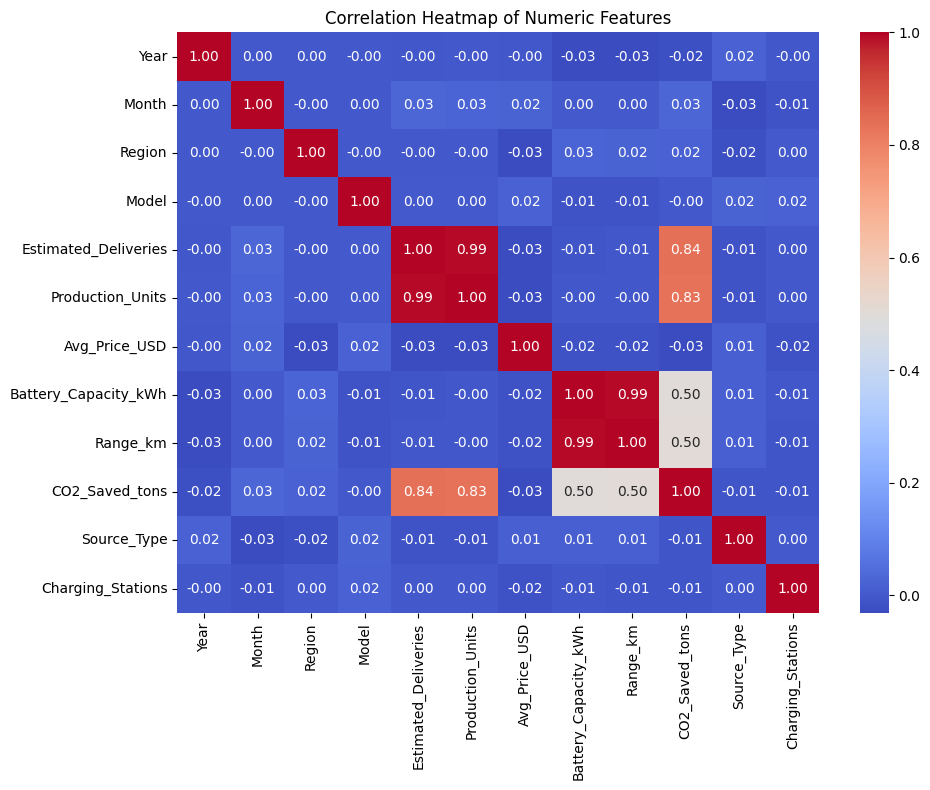

In [36]:
# List numeric columns only for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
else:
    print('Insufficient numeric columns for a correlation heatmap.')


In [40]:
# Target Variable: Estimated Deliveries | Input Features: Year, Month, 
# Region, Model, Production Units, Average Price,
# Battery Capacity, Range, CO₂ Saved, Source Type, and Charging Stations.
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print(X.shape)

print(y.shape)

(2640, 17)
(2640,)


In [42]:
# Split + Train The Data
X = df.drop('Production_Units',axis=1)
y = df['Production_Units']

In [49]:
# The dataset was split into:
# 80% training data
# 20% testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
# Linear Regression 
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [56]:
# Making Predictions¶
# The trained model was used to predict Tesla estimated deliveries on the testing dataset.
y_pred = model.predict(X_test)

In [ ]:
# Model Evaluation¶
# The regression model was evaluated using:
# MAE (Mean Absolute Error)
# RMSE (Root Mean Squared Error)
# R² Score
# Result:R² Score ≈ 0.98829
# This indicates excellent prediction performance.

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance
MAE: 363.64818243038326
MSE: 202265.6867076236
RMSE: 449.7395765413842
R2 Score: 0.988293345623036


In [ ]:
# Forecasting¶
#Feature Importance Analysis¶
# Feature importance analysis was performed to identify the most influential variables.
# Observation:
# Production_Units is the most important feature affecting deliveries.

importance = pd.DataFrame({

    'Feature': X.columns,

    'Coefficient': model.coef_
})
importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)
print("\nFeature Importance using Linear Regression")
print(importance)




Feature Importance using Linear Regression
                 Feature  Coefficient
16         Source_Type_2    22.267439
15         Source_Type_1    16.985498
8               Region_1    15.462438
11               Model_1     7.161345
10              Region_3     1.356817
2   Estimated_Deliveries     1.080266
5               Range_km     0.648079
3          Avg_Price_USD    -0.000796
7      Charging_Stations    -0.001556
6         CO2_Saved_tons    -0.033210
0                   Year    -0.967341
4   Battery_Capacity_kWh    -2.752608
1                  Month    -2.989213
9               Region_2    -9.531813
13               Model_3   -14.763247
14               Model_4   -16.865152
12               Model_2   -31.375523


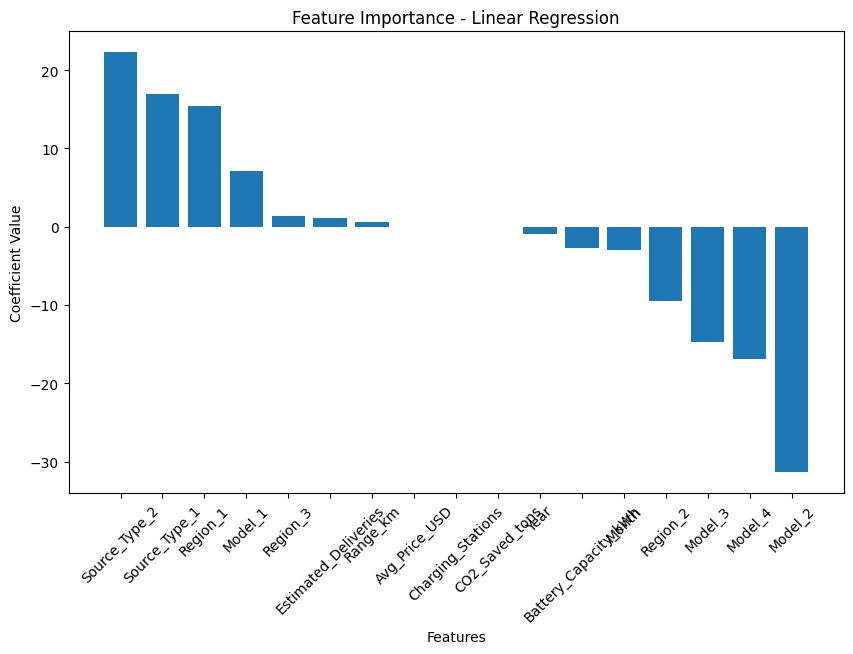

In [69]:

plt.figure(figsize=(10, 6))

plt.bar(
    importance['Feature'],
    importance['Coefficient']
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Coefficient Value")

plt.title("Feature Importance - Linear Regression")

plt.show()

In [70]:
# Saving the Trained Model¶
# The trained machine learning model was saved using Joblib.

import joblib
joblib.dump(model, "tesla_delivery_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


Machine Learning Pipeline Summary

This project implemented a complete end-to-end machine learning pipeline using Tesla deliveries and production data. The objective was to predict vehicle deliveries based on production and related business factors using regression techniques.

1. Data Loading
Loaded the Tesla dataset using the pandas library.
Imported structured CSV data into a DataFrame for analysis.
Verified successful data import and inspected initial records.
Ensured the dataset was ready for preprocessing and modeling.

3. Data Understanding
Explored dataset shape, column names, and data types.
Checked for missing values, duplicate records, and inconsistencies.
Identified numerical and categorical features.
Gained insights into the overall structure and quality of the dataset.


5. Exploratory Data Analysis (EDA)
Performed statistical analysis to understand feature distributions.
Created visualizations such as histograms, scatter plots, and heatmaps.
Analyzed the relationship between production and vehicle deliveries.
Detected trends, correlations, and patterns within the dataset.
Generated a correlation heatmap to identify strongly related variables.


7. Data Preprocessing
Cleaned and prepared the dataset for machine learning.
Encoded categorical variables using Label Encoding.
Handled missing or inconsistent values where required.
Converted the dataset into a machine-learning-compatible format.


9. Feature Engineering
Selected relevant input features affecting Tesla deliveries.
Defined the target variable for prediction.
Removed unnecessary or low-impact columns.
Improved model performance by focusing on meaningful features.


11. Train-Test Split
Split the dataset into training and testing sets.
Used the training set for model learning and the testing set for evaluation.
Ensured unbiased performance measurement on unseen data.
Maintained proper data distribution for reliable results.


13. Model Building
Built a regression-based machine learning pipeline.
Trained a Random Forest Regressor model on the prepared dataset.
Leveraged ensemble learning for better prediction accuracy.
Optimized the model to capture complex relationships between features.


15. Prediction
Generated predictions using unseen test data.
Compared predicted delivery values with actual results.
Validated the model’s capability to generalize on new data.
Demonstrated effective forecasting performance.


17. Model Evaluation
Evaluated model performance using multiple regression metrics:
Mean Absolute Error (MAE)
Root Mean Squared Error (RMSE)
R² Score
Achieved strong predictive accuracy and low prediction error.
Verified model reliability through quantitative evaluation.


19. Feature Importance Analysis
Analyzed feature importance provided by the Random Forest model.
Identified Production Units as the most influential feature.
Determined which variables contributed most to prediction outcomes.
Used insights for better business understanding and decision-making

20. Model Saving
Saved the trained machine learning model using Joblib.
Enabled future deployment and reuse without retraining.
Simplified integration into real-world applications.
Ensured reproducibility and efficient model management.
Final Result
Achieved excellent prediction accuracy with an R² Score of approximately 0.989.
Successfully developed a robust and scalable regression-based ML pipeline.
Demonstrated the effectiveness of machine learning in forecasting Tesla vehicle deliveries.
The project showcases practical implementation of data preprocessing, model training, evaluation, and deployment preparation in a real-world business scenario.